In [1]:
# Install required libraries
!pip install lazypredict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.9 MB/s eta 0:00:00


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

In [3]:
# Load the Iris dataset
from datasets import load_dataset
ds = load_dataset("scikit-learn/iris")

# Convert to pandas DataFrame
df = ds['train'].to_pandas()

# Preview
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nClass distribution:")
print(df['Species'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

README.md: 0.00B [00:00, ?B/s]

Iris.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/150 [00:00<?, ? examples/s]

Dataset Shape: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1           5.10          3.50           1.40          0.20  Iris-setosa
1   2           4.90          3.00           1.40          0.20  Iris-setosa
2   3           4.70          3.20           1.30          0.20  Iris-setosa
3   4           4.60          3.10           1.50          0.20  Iris-setosa
4   5           5.00          3.60           1.40          0.20  Iris-setosa

Column names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing values: 0


In [4]:
from sklearn.preprocessing import LabelEncoder

# Drop the Id column (not a feature)
df = df.drop(columns=['Id'])

# Encode target variable (Iris-setosa → 0, etc.)
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Split features and target
X = df.drop(columns=['Species'])
y = df['Species']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features used:", X.columns.tolist())
print("Encoded classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# Run LazyClassifier (the AutoML pipeline!)
print("Running AutoML with LazyPredict")
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("All Model Results:")
print(models)

Training samples: 120
Testing samples: 30
Features used: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Encoded classes: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Running AutoML with LazyPredict


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.073920
[LightGBM] [Info] Start training from score -1.123930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

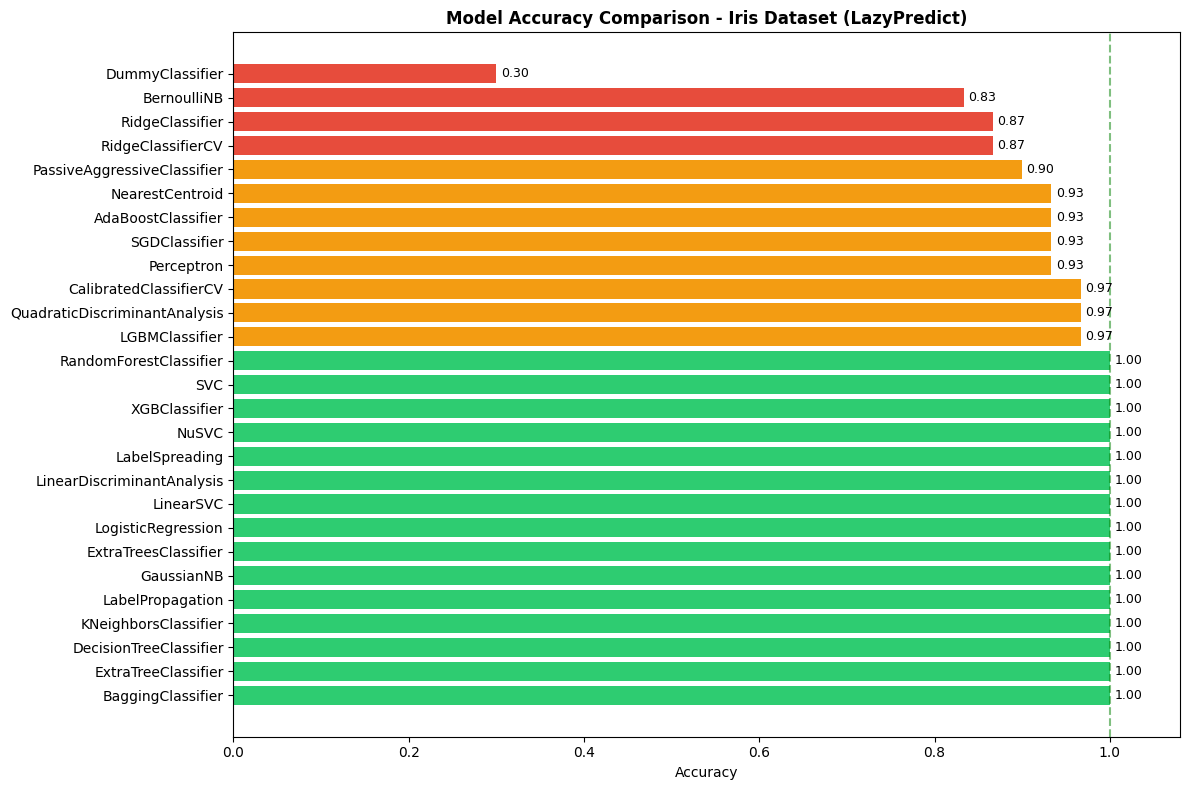

In [8]:
#Cell 1: Model Accuracy Comparison
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if acc == 1.0 else '#e74c3c' if acc < 0.90 else '#f39c12'
          for acc in models['Accuracy']]
bars = plt.barh(models.index, models['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison - Iris Dataset (LazyPredict)', fontweight='bold')
plt.xlim(0, 1.08)
plt.axvline(x=1.0, color='green', linestyle='--', alpha=0.5)
for bar, val in zip(bars, models['Accuracy']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot1_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

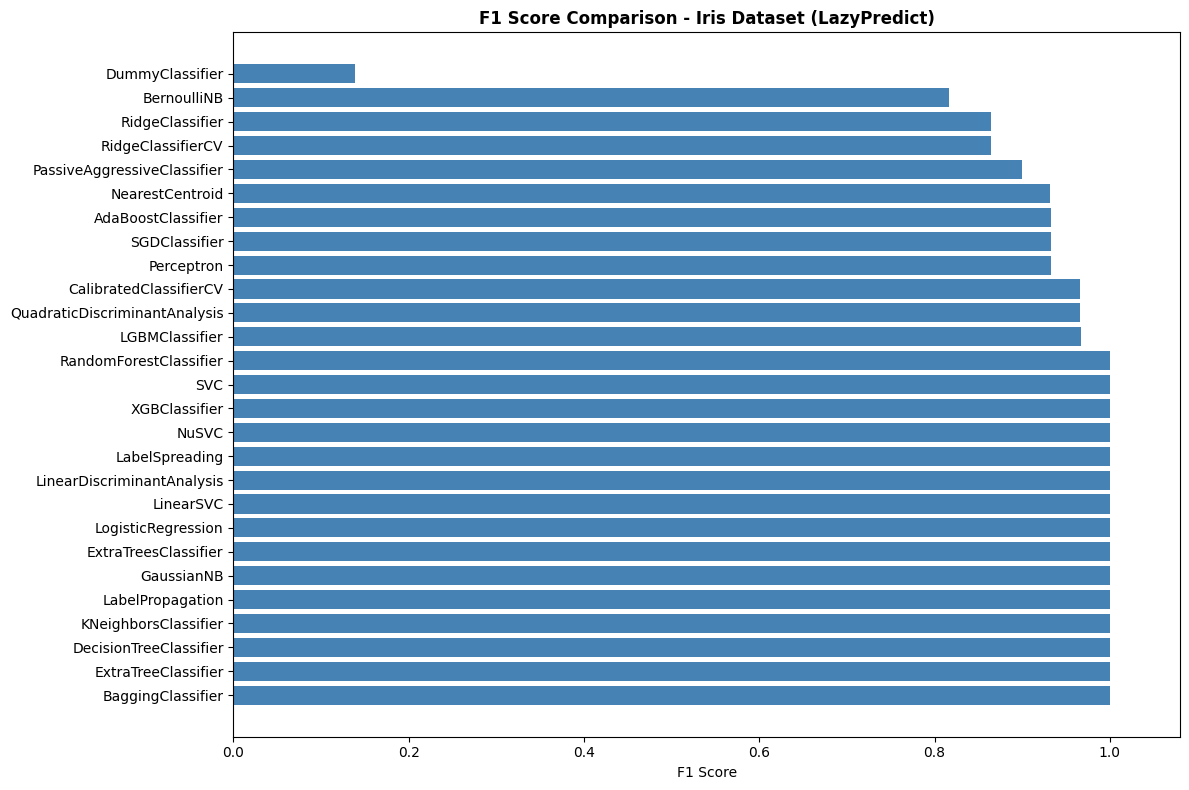

In [9]:
#Cell 2: F1 Score Comparison
plt.figure(figsize=(12, 8))
plt.barh(models.index, models['F1 Score'], color='steelblue')
plt.xlabel('F1 Score')
plt.title('F1 Score Comparison - Iris Dataset (LazyPredict)', fontweight='bold')
plt.xlim(0, 1.08)
plt.tight_layout()
plt.savefig('plot2_f1score.png', dpi=150, bbox_inches='tight')
plt.show()

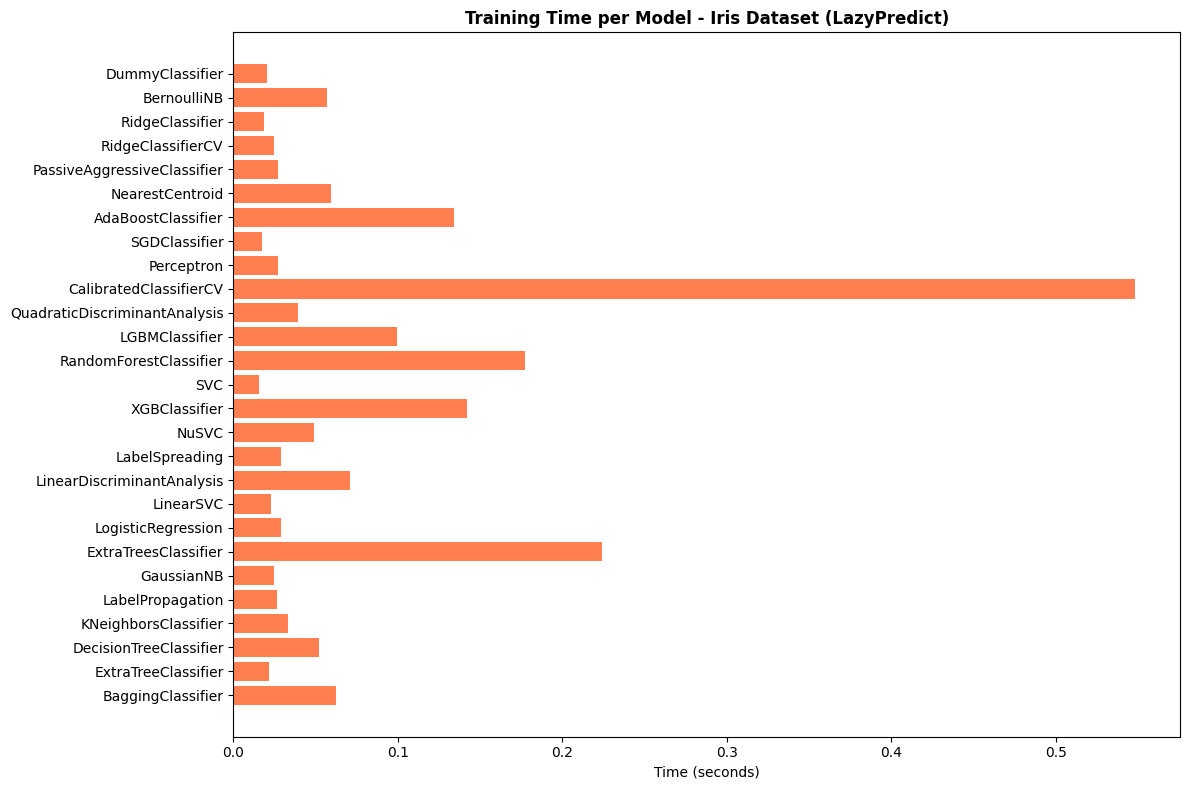

In [10]:
#Cell 3:  Training Time
plt.figure(figsize=(12, 8))
plt.barh(models.index, models['Time Taken'], color='coral')
plt.xlabel('Time (seconds)')
plt.title('Training Time per Model - Iris Dataset (LazyPredict)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_time.png', dpi=150, bbox_inches='tight')
plt.show()

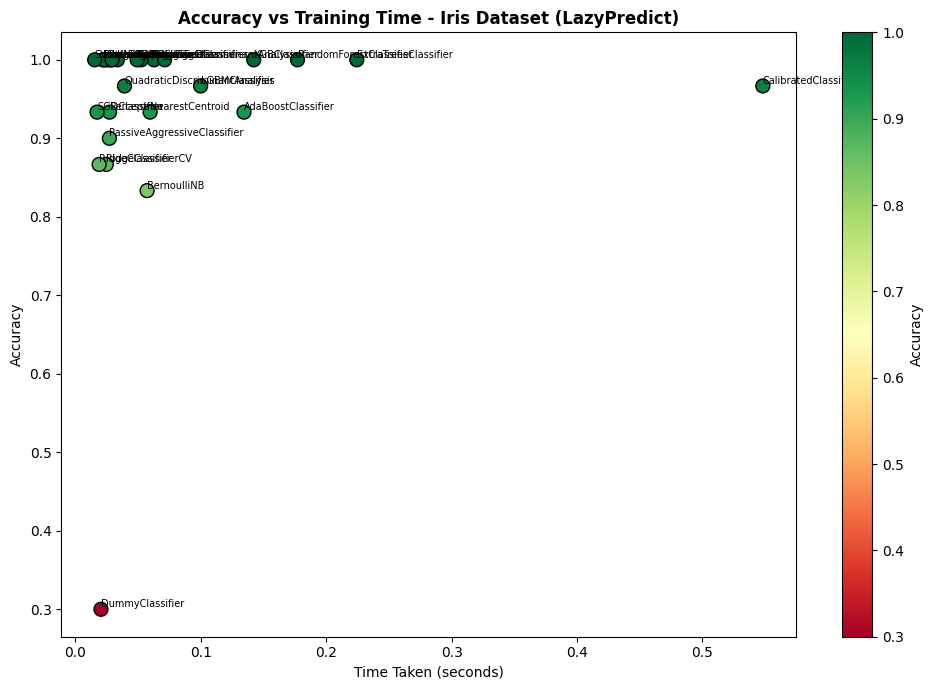

In [11]:
#Cell 4: Accuracy vs Training Time Scatter
plt.figure(figsize=(10, 7))
scatter = plt.scatter(models['Time Taken'], models['Accuracy'],
                      c=models['Accuracy'], cmap='RdYlGn', s=100, edgecolors='black')
for i, model_name in enumerate(models.index):
    plt.annotate(model_name, (models['Time Taken'].iloc[i], models['Accuracy'].iloc[i]),
                fontsize=7, ha='left', va='bottom')
plt.xlabel('Time Taken (seconds)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Training Time - Iris Dataset (LazyPredict)', fontweight='bold')
plt.colorbar(scatter, label='Accuracy')
plt.tight_layout()
plt.savefig('plot4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()